# 1. Construction and Validation of a Scalar Team-Strength Index

The previous opponent-adjustment model represents each team using separate
four-dimensional home and away seasonal state vectors:

$$
\widehat{\boldsymbol{\alpha}}_{i,v}^{(t)}
=
\begin{bmatrix}
\widehat{\alpha}_{i,v,\mathrm{Shot}}^{(t)}\\
\widehat{\alpha}_{i,v,\mathrm{SOT}}^{(t)}\\
\widehat{\alpha}_{i,v,\mathrm{Finishing}}^{(t)}\\
\widehat{\alpha}_{i,v,\mathrm{Corners}}^{(t)}
\end{bmatrix}.
$$

Although the vector representation preserves the different dimensions of team
performance, later comparison with league ranking, Elo, and the dynamic
Bayesian state requires a one-dimensional summary of overall strength.

For each venue, define

$$
S_{i,v}^{(t)}
=
\mathbf{w}_v^\top
\widehat{\boldsymbol{\alpha}}_{i,v}^{(t)},
$$

where

$$
w_{v,k}\geq 0,
\qquad
\sum_{k=1}^{4} w_{v,k}=1.
$$

Home and away weights are estimated separately because the two venue-specific
state vectors are intentionally preserved throughout the model.

The weights are calibrated using historical league-performance ordering and
are subsequently frozen before comparison with Elo or use in the Bayesian
dynamic model.

In [1]:
import numpy as np
import pandas as pd

from scipy.stats import spearmanr, kendalltau

RESULT_FILE = "team_strength_all_results.xlsx"

alpha_long = pd.read_excel(
    RESULT_FILE,
    sheet_name="Team_Baseline_Alpha"
)

e0_matches = pd.read_excel(
    RESULT_FILE,
    sheet_name="E0_Standardized"
)

print(alpha_long.shape)
display(alpha_long.head())

print(e0_matches.shape)
display(e0_matches.head())

(1760, 9)


,League,Season,Team,Venue,Feature,N_Matches,Mean_z,Mean_q,Baseline_Alpha
0,E0,2021-22,Arsenal,Home,Shot_Diff,19,0.906549,-0.045777,0.886679
1,E0,2021-22,Aston Villa,Home,Shot_Diff,19,0.053642,0.021214,0.062850
2,E0,2021-22,Brentford,Home,Shot_Diff,19,0.069735,0.018422,0.077731
3,E0,2021-22,Brighton,Home,Shot_Diff,19,0.278938,0.004466,0.280877
4,E0,2021-22,Burnley,Home,Shot_Diff,19,-0.166290,0.049126,-0.144966


(3800, 33)


,Season,Date,Team,Opponent,Venue,GF,GA,Shots_For,Shots_Against,SOT_For,...,SOT_Rate_Against,Goal_per_Shot_Against,Goal_per_SOT_Against,Goal_per_Shot_Diff,SOT_Diff,Goal_Diff,z_Shot_Diff,z_SOT_Rate_Diff,z_Finishing_Diff,z_Corners_Diff
0,2021-22,2021-08-13,Arsenal,Brentford,Away,0,2,22,8,4,...,0.375000,0.250000,0.666667,-0.250000,1,-2,1.426876,-0.866092,-1.715897,0.633457
1,2021-22,2021-08-13,Brentford,Arsenal,Home,2,0,8,22,3,...,0.181818,0.000000,0.000000,0.250000,-1,2,-1.426876,0.866092,1.715897,-0.633457
2,2021-22,2021-08-14,Aston Villa,Watford,Away,2,3,11,13,2,...,0.538462,0.230769,0.428571,-0.048951,-5,-1,-0.203839,-1.598938,1.470769,0.422304
3,2021-22,2021-08-14,Brighton,Burnley,Away,2,1,14,14,8,...,0.214286,0.071429,0.333333,0.071429,5,1,0.000000,1.601178,-0.214487,-0.211152
4,2021-22,2021-08-14,Burnley,Brighton,Home,1,2,14,14,3,...,0.571429,0.142857,0.250000,-0.071429,-5,-1,0.000000,-1.601178,0.214487,0.211152


In [2]:
print(alpha_long.columns.tolist())
print(e0_matches.columns.tolist())

['League', 'Season', 'Team', 'Venue', 'Feature', 'N_Matches', 'Mean_z', 'Mean_q', 'Baseline_Alpha']
['Season', 'Date', 'Team', 'Opponent', 'Venue', 'GF', 'GA', 'Shots_For', 'Shots_Against', 'SOT_For', 'SOT_Against', 'Corners_For', 'Corners_Against', 'Yellow', 'Red', 'Points', 'SOT_Rate', 'Goal_per_Shot', 'Goal_per_SOT', 'Shot_Diff', 'SOT_Rate_Diff', 'Finishing_Diff', 'Corners_Diff', 'SOT_Rate_Against', 'Goal_per_Shot_Against', 'Goal_per_SOT_Against', 'Goal_per_Shot_Diff', 'SOT_Diff', 'Goal_Diff', 'z_Shot_Diff', 'z_SOT_Rate_Diff', 'z_Finishing_Diff', 'z_Corners_Diff']


In [3]:
FEATURES = [
    "Shot_Diff",
    "SOT_Rate_Diff",
    "Finishing_Diff",
    "Corners_Diff",
]

e0_alpha = (
    alpha_long.loc[
        alpha_long["League"] == "E0"
    ]
    .pivot_table(
        index=[
            "Season",
            "Team",
            "Venue"
        ],
        columns="Feature",
        values="Baseline_Alpha"
    )
    .reset_index()
)

# Make the feature column names explicit
e0_alpha.columns.name = None

display(
    e0_alpha
    .sort_values(
        ["Season", "Team", "Venue"]
    )
    .head(20)
)

print(
    "\nShape:",
    e0_alpha.shape
)

,Season,Team,Venue,Corners_Diff,Finishing_Diff,SOT_Rate_Diff,Shot_Diff
0,2021-22,Arsenal,Away,-0.194507,-0.146501,-0.218024,-0.052137
1,2021-22,Arsenal,Home,0.529218,-0.051989,-0.001952,0.886679
2,2021-22,Aston Villa,Away,-0.103396,0.107306,0.081495,-0.167772
3,2021-22,Aston Villa,Home,-0.170707,0.237220,0.167947,0.062850
4,2021-22,Brentford,Away,-0.593398,0.041436,-0.129069,-0.383557
5,2021-22,Brentford,Home,-0.204982,-0.032079,-0.010556,0.077731
6,2021-22,Brighton,Away,-0.442902,0.016412,0.612312,-0.201893
7,2021-22,Brighton,Home,0.334894,-0.283449,-0.300924,0.280877
8,2021-22,Burnley,Away,-0.682220,0.013130,0.009012,-0.863680
9,2021-22,Burnley,Home,-0.072452,-0.140547,-0.161083,-0.144966



Shape: (200, 7)


In [4]:
check = (
    e0_alpha
    .groupby(["Season", "Venue"])
    ["Team"]
    .nunique()
)

display(check)

Season   Venue
2021-22  Away     20
         Home     20
2022-23  Away     20
         Home     20
2023-24  Away     20
         Home     20
2024-25  Away     20
         Home     20
2025-26  Away     20
         Home     20
Name: Team, dtype: int64

In [5]:
def build_venue_table(
    match_df,
    venue
):
    """
    Build a season-specific league table using only
    home or away matches.

    Ranking order:
    1. Points
    2. Goal difference
    3. Goals scored
    """

    df = match_df.loc[
        match_df["Venue"] == venue
    ].copy()

    table = (
        df.groupby(
            ["Season", "Team"],
            as_index=False
        )
        .agg(
            Points=("Points", "sum"),
            GF=("GF", "sum"),
            GA=("GA", "sum"),
            Matches=("Team", "size")
        )
    )

    table["GD"] = (
        table["GF"]
        -
        table["GA"]
    )

    tables = []

    for season, season_df in (
        table.groupby("Season")
    ):

        season_df = (
            season_df
            .sort_values(
                ["Points", "GD", "GF"],
                ascending=[
                    False,
                    False,
                    False
                ]
            )
            .reset_index(drop=True)
        )

        season_df["Rank"] = (
            np.arange(
                1,
                len(season_df) + 1
            )
        )

        # Higher = stronger, convenient for positive correlation
        season_df["Rank_Strength"] = (
            len(season_df)
            + 1
            - season_df["Rank"]
        )

        season_df["Venue"] = venue

        tables.append(
            season_df
        )

    return pd.concat(
        tables,
        ignore_index=True
    )


home_table = build_venue_table(
    e0_matches,
    "Home"
)

away_table = build_venue_table(
    e0_matches,
    "Away"
)

venue_tables = pd.concat(
    [
        home_table,
        away_table
    ],
    ignore_index=True
)

display(
    venue_tables.head(20)
)

,Season,Team,Points,GF,GA,Matches,GD,Rank,Rank_Strength,Venue
0,2021-22,Liverpool,49,49,9,19,40,1,20,Home
1,2021-22,Man City,47,58,15,19,43,2,19,Home
2,2021-22,Arsenal,41,35,17,19,18,3,18,Home
3,2021-22,Tottenham,40,38,19,19,19,4,17,Home
4,2021-22,Man United,35,32,22,19,10,5,16,Home
5,2021-22,Chelsea,34,37,22,19,15,6,15,Home
6,2021-22,Leicester,34,34,23,19,11,7,14,Home
7,2021-22,West Ham,32,33,26,19,7,8,13,Home
8,2021-22,Newcastle,30,26,27,19,-1,9,12,Home
9,2021-22,Crystal Palace,29,27,17,19,10,10,11,Home


In [6]:
calibration_data = (
    e0_alpha
    .merge(
        venue_tables[
            [
                "Season",
                "Team",
                "Venue",
                "Points",
                "GF",
                "GA",
                "GD",
                "Matches",
                "Rank",
                "Rank_Strength"
            ]
        ],
        on=[
            "Season",
            "Team",
            "Venue"
        ],
        how="inner",
        validate="one_to_one"
    )
)

display(
    calibration_data
    .sort_values(
        ["Season", "Venue", "Rank"]
    )
    .head(30)
)

print(
    calibration_data.shape
)

,Season,Team,Venue,Corners_Diff,Finishing_Diff,SOT_Rate_Diff,Shot_Diff,Points,GF,GA,GD,Matches,Rank,Rank_Strength
22,2021-22,Man City,Away,0.836822,0.435039,0.096521,1.130972,46,41,11,30,19,1,20
20,2021-22,Liverpool,Away,0.804501,0.229598,-0.030511,0.826430,43,45,17,28,19,2,19
10,2021-22,Chelsea,Away,0.222707,0.562648,0.132072,0.499656,40,39,11,28,19,3,18
32,2021-22,Tottenham,Away,-0.196543,-0.172569,0.612834,-0.210132,31,31,21,10,19,4,17
6,2021-22,Brighton,Away,-0.442902,0.016412,0.612312,-0.201893,29,23,21,2,19,5,16
0,2021-22,Arsenal,Away,-0.194507,-0.146501,-0.218024,-0.052137,28,26,31,-5,19,6,15
38,2021-22,Wolves,Away,-0.265090,0.113011,0.441720,-0.572022,27,18,18,0,19,7,14
36,2021-22,West Ham,Away,-0.214613,0.050598,0.397877,-0.556648,24,27,25,2,19,8,13
24,2021-22,Man United,Away,-0.083290,-0.051645,-0.018721,-0.242594,23,25,35,-10,19,9,12
2,2021-22,Aston Villa,Away,-0.103396,0.107306,0.081495,-0.167772,22,23,25,-2,19,10,11


(200, 14)


In [7]:
equal_weights = np.array([
    0.25,
    0.25,
    0.25,
    0.25
])

calibration_data[
    "Strength_Equal"
] = (
    calibration_data[FEATURES]
    .to_numpy()
    @ equal_weights
)


equal_weight_results = []

for (
    season,
    venue
), group in calibration_data.groupby(
    ["Season", "Venue"]
):

    spearman_r, spearman_p = spearmanr(
        group["Strength_Equal"],
        group["Rank_Strength"]
    )

    kendall_tau, kendall_p = kendalltau(
        group["Strength_Equal"],
        group["Rank_Strength"]
    )

    equal_weight_results.append({
        "Season": season,
        "Venue": venue,
        "Spearman": spearman_r,
        "Spearman_p": spearman_p,
        "Kendall_tau": kendall_tau,
        "Kendall_p": kendall_p
    })


equal_weight_results = pd.DataFrame(
    equal_weight_results
)

display(
    equal_weight_results.round(4)
)

,Season,Venue,Spearman,Spearman_p,Kendall_tau,Kendall_p
0,2021-22,Away,0.8692,0.0000,0.7368,0.0000
1,2021-22,Home,0.9278,0.0000,0.8211,0.0000
2,2022-23,Away,0.8451,0.0000,0.6737,0.0000
3,2022-23,Home,0.8271,0.0000,0.6211,0.0001
4,2023-24,Away,0.7699,0.0001,0.6105,0.0001
5,2023-24,Home,0.9263,0.0000,0.8211,0.0000
6,2024-25,Away,0.8150,0.0000,0.6421,0.0000
7,2024-25,Home,0.8857,0.0000,0.7368,0.0000
8,2025-26,Away,0.8647,0.0000,0.7053,0.0000
9,2025-26,Home,0.8105,0.0000,0.6632,0.0000


In [9]:
def evaluate_weights(
    df,
    weights,
    venue,
    seasons=None
):
    """
    Average season-by-season Spearman correlation.
    """

    sample = df.loc[
        df["Venue"] == venue
    ].copy()

    if seasons is not None:
        sample = sample.loc[
            sample["Season"].isin(
                seasons
            )
        ]

    sample["Strength"] = (
        sample[FEATURES]
        .to_numpy()
        @ weights
    )

    season_scores = []

    for season, group in (
        sample.groupby("Season")
    ):

        rho, _ = spearmanr(
            group["Strength"],
            group["Rank_Strength"]
        )

        season_scores.append(rho)

    return np.mean(
        season_scores
    )


def random_weight_search(
    df,
    venue,
    seasons,
    n_iter=20000,
    seed=42
):
    rng = np.random.default_rng(
        seed
    )

    best_score = -np.inf
    best_weights = None

    records = []

    for _ in range(n_iter):

        weights = rng.dirichlet(
            np.ones(len(FEATURES))
        )

        score = evaluate_weights(
            df=df,
            weights=weights,
            venue=venue,
            seasons=seasons
        )

        records.append({
            "Shot_Diff": weights[0],
            "SOT_Rate_Diff": weights[1],
            "Finishing_Diff": weights[2],
            "Corners_Diff": weights[3],
            "Mean_Spearman": score
        })

        if score > best_score:
            best_score = score
            best_weights = weights.copy()

    results = (
        pd.DataFrame(records)
        .sort_values(
            "Mean_Spearman",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return (
        best_weights,
        best_score,
        results
    )

## 2. Leave-One-Season-Out Weight Calibration

The equal-weight index already provides a strong baseline. Therefore,
non-equal feature weights should only be retained if they improve
out-of-sample ranking agreement.

A leave-one-season-out procedure is used separately for home and away states.

For each held-out season:

1. the remaining four seasons are used to search for the weight vector
   $\mathbf{w}_v$ that maximizes mean Spearman rank correlation;
2. the selected weights are frozen;
3. the resulting scalar index is evaluated on the held-out season;
4. its performance is compared with the equal-weight benchmark.

This procedure separates weight calibration from evaluation and reduces the
risk of selecting weights that merely overfit historical league rankings.

In [10]:
# --------------------------------------------------
# Leave-One-Season-Out random weight search
# --------------------------------------------------

all_seasons = sorted(
    calibration_data["Season"].unique()
)

equal_weights = np.array([
    0.25,
    0.25,
    0.25,
    0.25
])

loso_records = []
loso_weight_records = []


for venue in ["Home", "Away"]:

    print(f"\n===== {venue} =====")

    for test_season in all_seasons:

        train_seasons = [
            season
            for season in all_seasons
            if season != test_season
        ]

        # ------------------------------
        # 1. Search weights on 4 seasons
        # ------------------------------
        (
            best_weights,
            best_train_score,
            search_results
        ) = random_weight_search(
            df=calibration_data,
            venue=venue,
            seasons=train_seasons,
            n_iter=20000,
            seed=42
        )

        # ------------------------------
        # 2. Held-out test data
        # ------------------------------
        test_df = calibration_data.loc[
            (calibration_data["Venue"] == venue)
            &
            (calibration_data["Season"] == test_season)
        ].copy()

        # Optimized score
        test_df["Strength_Optimized"] = (
            test_df[FEATURES]
            .to_numpy()
            @ best_weights
        )

        # Equal-weight score
        test_df["Strength_Equal"] = (
            test_df[FEATURES]
            .to_numpy()
            @ equal_weights
        )

        # ------------------------------
        # 3. Spearman correlations
        # ------------------------------
        opt_spearman, opt_sp_p = spearmanr(
            test_df["Strength_Optimized"],
            test_df["Rank_Strength"]
        )

        eq_spearman, eq_sp_p = spearmanr(
            test_df["Strength_Equal"],
            test_df["Rank_Strength"]
        )

        # ------------------------------
        # 4. Kendall correlations
        # ------------------------------
        opt_kendall, opt_k_p = kendalltau(
            test_df["Strength_Optimized"],
            test_df["Rank_Strength"]
        )

        eq_kendall, eq_k_p = kendalltau(
            test_df["Strength_Equal"],
            test_df["Rank_Strength"]
        )

        # ------------------------------
        # 5. Save validation results
        # ------------------------------
        loso_records.append({
            "Venue": venue,
            "Test_Season": test_season,

            "Train_Mean_Spearman":
                best_train_score,

            "Equal_Test_Spearman":
                eq_spearman,

            "Optimized_Test_Spearman":
                opt_spearman,

            "Spearman_Improvement":
                opt_spearman - eq_spearman,

            "Equal_Test_Kendall":
                eq_kendall,

            "Optimized_Test_Kendall":
                opt_kendall,

            "Kendall_Improvement":
                opt_kendall - eq_kendall
        })

        # ------------------------------
        # 6. Save selected weights
        # ------------------------------
        loso_weight_records.append({
            "Venue": venue,
            "Test_Season": test_season,

            "Shot_Diff":
                best_weights[0],

            "SOT_Rate_Diff":
                best_weights[1],

            "Finishing_Diff":
                best_weights[2],

            "Corners_Diff":
                best_weights[3]
        })


loso_results = pd.DataFrame(
    loso_records
)

loso_weights = pd.DataFrame(
    loso_weight_records
)


===== Home =====

===== Away =====


In [12]:
display(
    loso_results.round(4)
)

,Venue,Test_Season,Train_Mean_Spearman,Equal_Test_Spearman,Optimized_Test_Spearman,Spearman_Improvement,Equal_Test_Kendall,Optimized_Test_Kendall,Kendall_Improvement
0,Home,2021-22,0.9180,0.9278,0.9489,0.0211,0.8211,0.8632,0.0421
1,Home,2022-23,0.9346,0.8271,0.8451,0.0180,0.6211,0.6526,0.0316
2,Home,2023-24,0.9241,0.9263,0.8902,-0.0361,0.8211,0.7368,-0.0842
3,Home,2024-25,0.9331,0.8857,0.8887,0.0030,0.7368,0.7263,-0.0105
4,Home,2025-26,0.9188,0.8105,0.9233,0.1128,0.6632,0.8105,0.1474
5,Away,2021-22,0.8929,0.8692,0.8586,-0.0105,0.7368,0.7158,-0.0211
6,Away,2022-23,0.8902,0.8451,0.8707,0.0256,0.6737,0.6947,0.0211
7,Away,2023-24,0.8910,0.7699,0.8451,0.0752,0.6105,0.6947,0.0842
8,Away,2024-25,0.8910,0.8150,0.8301,0.0150,0.6421,0.6737,0.0316
9,Away,2025-26,0.8921,0.8647,0.8767,0.0120,0.7053,0.7263,0.0211


In [13]:
# --------------------------------------------------
# Overall LOSO comparison
# --------------------------------------------------

loso_summary = (
    loso_results
    .groupby("Venue")
    .agg(
        Equal_Mean_Spearman=(
            "Equal_Test_Spearman",
            "mean"
        ),

        Optimized_Mean_Spearman=(
            "Optimized_Test_Spearman",
            "mean"
        ),

        Mean_Spearman_Improvement=(
            "Spearman_Improvement",
            "mean"
        ),

        Equal_Mean_Kendall=(
            "Equal_Test_Kendall",
            "mean"
        ),

        Optimized_Mean_Kendall=(
            "Optimized_Test_Kendall",
            "mean"
        ),

        Mean_Kendall_Improvement=(
            "Kendall_Improvement",
            "mean"
        ),

        Seasons_Improved=(
            "Spearman_Improvement",
            lambda x: (x > 0).sum()
        )
    )
    .reset_index()
)

display(
    loso_summary.round(4)
)

,Venue,Equal_Mean_Spearman,Optimized_Mean_Spearman,Mean_Spearman_Improvement,Equal_Mean_Kendall,Optimized_Mean_Kendall,Mean_Kendall_Improvement,Seasons_Improved
0,Away,0.8328,0.8562,0.0235,0.6737,0.7011,0.0274,4
1,Home,0.8755,0.8992,0.0238,0.7326,0.7579,0.0253,4


### 2.1 Equal-Weight Baseline

Before optimizing the feature weights, an equal-weight strength index was
constructed as

$$
S_{i,v}^{(t)}
=
0.25\widehat{\alpha}_{i,v,\mathrm{Shot}}^{(t)}
+
0.25\widehat{\alpha}_{i,v,\mathrm{SOT}}^{(t)}
+
0.25\widehat{\alpha}_{i,v,\mathrm{Finishing}}^{(t)}
+
0.25\widehat{\alpha}_{i,v,\mathrm{Corners}}^{(t)}.
$$

The resulting scalar index was compared with the venue-specific league
ordering in each season using Spearman rank correlation and Kendall's
$\tau$.

Even without optimizing the weights, the equal-weight index showed a
consistently strong positive association with league performance across all
five seasons and both venues. The season-specific Spearman correlations were
approximately between $0.77$ and $0.93$, while the corresponding Kendall
coefficients remained strongly positive.

The mean Spearman correlations across the five seasons were approximately

$$
\bar{\rho}_{\mathrm{Home}} = 0.876,
\qquad
\bar{\rho}_{\mathrm{Away}} = 0.833.
$$

These results provide an important baseline. They indicate that the
four-dimensional opponent-adjusted state vector already contains substantial
information about team strength even when all four components receive equal
weight.

Therefore, subsequent weight optimization is not intended to establish
whether the state vector contains strength information. Instead, it tests
whether a non-equal projection of the four state dimensions can provide a
more stable and accurate representation of team strength out of sample.

### 2.2 Leave-One-Season-Out Weight Optimization Results

To determine whether non-equal weights improve the scalar strength index,
the weight calibration was evaluated using leave-one-season-out validation.

For each venue and each held-out season, the remaining four seasons were used
to search over candidate weight vectors satisfying

$$
w_{v,k}\geq 0,
\qquad
\sum_{k=1}^{4}w_{v,k}=1.
$$

Candidate weights were generated from a Dirichlet distribution, and the
weight vector maximizing the mean training-season Spearman correlation was
selected. The selected weights were then frozen and evaluated on the season
that had not participated in the calibration.

Across the five held-out seasons, the optimized index achieved mean Spearman
correlations of approximately

$$
\bar{\rho}_{\mathrm{Home}}^{\mathrm{opt}}
=
0.899,
$$

and

$$
\bar{\rho}_{\mathrm{Away}}^{\mathrm{opt}}
=
0.856.
$$

Compared with the equal-weight benchmark, the average out-of-sample
improvements were therefore approximately

$$
\Delta\bar{\rho}_{\mathrm{Home}}
=
0.024,
$$

and

$$
\Delta\bar{\rho}_{\mathrm{Away}}
=
0.024.
$$

The optimized index improved the held-out Spearman correlation in four of
the five seasons for both home and away states.

Kendall's $\tau$ showed a similar pattern. The mean coefficient increased
from approximately

$$
0.733 \rightarrow 0.758
$$

for home states and

$$
0.674 \rightarrow 0.701
$$

for away states.

The agreement between the Spearman and Kendall results indicates that the
improvement is not limited to a single ranking metric. The optimized
projection improves both the overall ordering of teams and the pairwise
consistency of the inferred strength ranking.

In [14]:
display(
    loso_weights.round(4)
)

,Venue,Test_Season,Shot_Diff,SOT_Rate_Diff,Finishing_Diff,Corners_Diff
0,Home,2021-22,0.2971,0.2501,0.3776,0.0752
1,Home,2022-23,0.2855,0.3620,0.2613,0.0911
2,Home,2023-24,0.2474,0.3109,0.3703,0.0715
3,Home,2024-25,0.2971,0.2501,0.3776,0.0752
4,Home,2025-26,0.2263,0.3283,0.2994,0.1459
5,Away,2021-22,0.2304,0.1233,0.5295,0.1167
6,Away,2022-23,0.2950,0.1368,0.5259,0.0423
7,Away,2023-24,0.3434,0.2157,0.4170,0.0238
8,Away,2024-25,0.2203,0.2460,0.4707,0.0630
9,Away,2025-26,0.3103,0.2032,0.4663,0.0202


In [15]:
weight_stability = (
    loso_weights
    .groupby("Venue")[FEATURES]
    .agg(["mean", "std", "min", "max"])
)

display(
    weight_stability.round(4)
)

Shot_Diff                         SOT_Rate_Diff                         \
           mean     std     min     max          mean     std     min    max   
Venue                                                                          
Away     0.2799  0.0529  0.2203  0.3434        0.1850  0.0527  0.1233  0.246   
Home     0.2707  0.0321  0.2263  0.2971        0.3003  0.0494  0.2501  0.362   

      Finishing_Diff                         Corners_Diff                  \
                mean     std     min     max         mean     std     min   
Venue                                                                       
Away          0.4819  0.0468  0.4170  0.5295       0.0532  0.0394  0.0202   
Home          0.3373  0.0537  0.2613  0.3776       0.0918  0.0312  0.0715   

               
          max  
Venue          
Away   0.1167  
Home   0.1459

### 2.3 Structure and Stability of the Selected Weights

The leave-one-season-out procedure also provides information about whether
the estimated feature importance is stable across different training
samples.

Averaging the selected weights across the five folds gives approximately

$$
\mathbf{w}_{H}
=
\begin{bmatrix}
0.271 &
0.300 &
0.337 &
0.092
\end{bmatrix},
$$

and

$$
\mathbf{w}_{A}
=
\begin{bmatrix}
0.280 &
0.185 &
0.482 &
0.053
\end{bmatrix},
$$

where the components correspond to

$$
[
\mathrm{Shot\ Diff},
\mathrm{SOT\ Rate\ Diff},
\mathrm{Finishing\ Diff},
\mathrm{Corners\ Diff}
].
$$

The home-state weights are relatively distributed among Shot Diff,
SOT Rate Diff, and Finishing Diff, with Corners Diff receiving a substantially
smaller weight.

The away-state projection shows a more concentrated structure. Finishing Diff
receives the largest weight, followed by Shot Diff and SOT Rate Diff, while
Corners Diff again receives relatively little weight.

Importantly, the selected weight vectors do not change arbitrarily across the
five leave-one-season-out folds. Their feature ordering and approximate
magnitudes remain reasonably stable, suggesting that the optimized weighting
structure is not solely driven by one particular season.

However, these coefficients should not be interpreted as direct causal
percentages of football strength. For example, an away Finishing Diff weight
near $0.48$ does not imply that finishing ability constitutes $48\%$ of a
team's true strength. Instead, the coefficients describe the projection of
the four opponent-adjusted state dimensions that best reproduces
venue-specific league-performance ordering under the present model.

### 2.4 Need for a Numerical Robustness Check

Although the leave-one-season-out results support the use of non-equal
weights, the optimization itself is based on random search.

Therefore, two distinct forms of stability must be separated:

1. **sample stability** — whether similar weights are obtained when different
   seasons are excluded from calibration;
2. **numerical stability** — whether similar weights are obtained when the
   random search is initialized with different random seeds.

The leave-one-season-out analysis provides evidence for the first form of
stability. A multi-seed repetition of the same calibration procedure is used
next to evaluate the second.

The final home and away weight vectors will only be frozen after both forms
of robustness have been examined.

## 3. Multi-Seed Robustness of the Weight Calibration

Because the weight optimization is performed by random search, the selected
weight vector may depend partly on the random candidate sequence.

To evaluate this source of numerical uncertainty, the complete
leave-one-season-out calibration is repeated using multiple random seeds.

A robust weighting structure should satisfy two conditions:

1. the held-out ranking performance should remain similar across seeds;
2. the relative importance of the four features should remain stable.

This analysis evaluates the numerical stability of the calibration procedure,
rather than introducing additional model fitting.

In [17]:
# --------------------------------------------------
# Multi-seed LOSO robustness check
# --------------------------------------------------

SEEDS = [1, 10, 42, 100, 2026]

multi_seed_records = []
multi_seed_weight_records = []


for seed in SEEDS:

    print(f"\n===== Seed {seed} =====")

    for venue in ["Home", "Away"]:

        for test_season in all_seasons:

            train_seasons = [
                season
                for season in all_seasons
                if season != test_season
            ]

            # ---------------------------------------
            # Search weights using four seasons
            # ---------------------------------------
            (
                best_weights,
                best_train_score,
                _
            ) = random_weight_search(
                df=calibration_data,
                venue=venue,
                seasons=train_seasons,
                n_iter=3000,
                seed=seed
            )

            # ---------------------------------------
            # Held-out season
            # ---------------------------------------
            test_df = calibration_data.loc[
                (calibration_data["Venue"] == venue)
                &
                (calibration_data["Season"] == test_season)
            ].copy()

            test_df["Strength_Optimized"] = (
                test_df[FEATURES]
                .to_numpy()
                @ best_weights
            )

            test_df["Strength_Equal"] = (
                test_df[FEATURES]
                .to_numpy()
                @ equal_weights
            )

            opt_spearman, _ = spearmanr(
                test_df["Strength_Optimized"],
                test_df["Rank_Strength"]
            )

            eq_spearman, _ = spearmanr(
                test_df["Strength_Equal"],
                test_df["Rank_Strength"]
            )

            opt_kendall, _ = kendalltau(
                test_df["Strength_Optimized"],
                test_df["Rank_Strength"]
            )

            # ---------------------------------------
            # Save validation performance
            # ---------------------------------------
            multi_seed_records.append({
                "Seed": seed,
                "Venue": venue,
                "Test_Season": test_season,
                "Train_Mean_Spearman": best_train_score,
                "Equal_Test_Spearman": eq_spearman,
                "Optimized_Test_Spearman": opt_spearman,
                "Spearman_Improvement":
                    opt_spearman - eq_spearman,
                "Optimized_Test_Kendall":
                    opt_kendall
            })

            # ---------------------------------------
            # Save weights
            # ---------------------------------------
            multi_seed_weight_records.append({
                "Seed": seed,
                "Venue": venue,
                "Test_Season": test_season,
                "Shot_Diff": best_weights[0],
                "SOT_Rate_Diff": best_weights[1],
                "Finishing_Diff": best_weights[2],
                "Corners_Diff": best_weights[3]
            })


multi_seed_results = pd.DataFrame(
    multi_seed_records
)

multi_seed_weights = pd.DataFrame(
    multi_seed_weight_records
)


===== Seed 1 =====

===== Seed 10 =====

===== Seed 42 =====

===== Seed 100 =====

===== Seed 2026 =====


In [18]:
seed_performance_summary = (
    multi_seed_results
    .groupby(["Seed", "Venue"])
    .agg(
        Mean_Optimized_Spearman=(
            "Optimized_Test_Spearman",
            "mean"
        ),
        Mean_Improvement=(
            "Spearman_Improvement",
            "mean"
        ),
        Seasons_Improved=(
            "Spearman_Improvement",
            lambda x: (x > 0).sum()
        )
    )
    .reset_index()
)

display(
    seed_performance_summary.round(4)
)

,Seed,Venue,Mean_Optimized_Spearman,Mean_Improvement,Seasons_Improved
0,1,Away,0.8340,0.0012,3
1,1,Home,0.8917,0.0162,2
2,10,Away,0.8520,0.0192,3
3,10,Home,0.9008,0.0253,2
4,42,Away,0.8505,0.0177,3
5,42,Home,0.8965,0.0211,3
6,100,Away,0.8635,0.0307,4
7,100,Home,0.9017,0.0262,3
8,2026,Away,0.8589,0.0262,3
9,2026,Home,0.9116,0.0361,4


In [19]:
multi_seed_weight_summary = (
    multi_seed_weights
    .groupby("Venue")[FEATURES]
    .agg([
        "mean",
        "std",
        "min",
        "max"
    ])
)

display(
    multi_seed_weight_summary.round(4)
)

Shot_Diff                         SOT_Rate_Diff                          \
           mean     std     min     max          mean     std     min     max   
Venue                                                                           
Away     0.2862  0.0448  0.1952  0.3608        0.1746  0.0523  0.0873  0.2592   
Home     0.2969  0.0365  0.1969  0.3835        0.2869  0.0472  0.2292  0.3849   

      Finishing_Diff                         Corners_Diff                  \
                mean     std     min     max         mean     std     min   
Venue                                                                       
Away          0.4804  0.0517  0.3591  0.5429       0.0588  0.0305  0.0236   
Home          0.3460  0.0461  0.2423  0.4016       0.0702  0.0231  0.0269   

               
          max  
Venue          
Away   0.1188  
Home   0.1401

In [20]:
weights_by_seed = (
    multi_seed_weights
    .groupby(
        ["Seed", "Venue"]
    )[FEATURES]
    .mean()
    .reset_index()
)

display(
    weights_by_seed.round(4)
)

,Seed,Venue,Shot_Diff,SOT_Rate_Diff,Finishing_Diff,Corners_Diff
0,1,Away,0.2884,0.1837,0.4693,0.0586
1,1,Home,0.3192,0.2801,0.3499,0.0508
2,10,Away,0.3071,0.1621,0.4765,0.0543
3,10,Home,0.2949,0.2967,0.3348,0.0736
4,42,Away,0.2696,0.1788,0.4847,0.0669
5,42,Home,0.2762,0.3013,0.3455,0.0770
6,100,Away,0.2970,0.1835,0.4827,0.0368
7,100,Home,0.2922,0.2828,0.3448,0.0802
8,2026,Away,0.2688,0.1649,0.4888,0.0775
9,2026,Home,0.3021,0.2735,0.3549,0.0694


### 3.1 Multi-Seed Robustness Results

The multi-seed experiment shows that the main conclusions of the weight
calibration are not strongly dependent on a particular random-search
initialization.

Across the tested random seeds, the optimized strength index continued to
produce positive mean out-of-sample improvements over the equal-weight
baseline for both home and away states. The magnitude of the improvement
varied across seeds and individual held-out seasons, indicating that the
non-equal weighting scheme does not uniformly outperform the equal-weight
benchmark in every single season. However, its average performance remained
consistently competitive and generally superior across repeated searches.

More importantly, the broad structure of the selected weights remained
stable across random seeds.

For the home state, the average weighting structure was approximately

$$
\bar{\mathbf{w}}_H
=
\begin{bmatrix}
0.297 &
0.287 &
0.346 &
0.070
\end{bmatrix},
$$

while for the away state it was approximately

$$
\bar{\mathbf{w}}_A
=
\begin{bmatrix}
0.286 &
0.175 &
0.480 &
0.059
\end{bmatrix}.
$$

The components correspond to

$$
[
\mathrm{Shot\ Diff},
\mathrm{SOT\ Rate\ Diff},
\mathrm{Finishing\ Diff},
\mathrm{Corners\ Diff}
].
$$

For home performance, Shot Diff, SOT Rate Diff, and Finishing Diff all retain
substantial contributions, while Corners Diff consistently receives a much
smaller weight.

For away performance, the structure is more concentrated. Finishing Diff
consistently receives the largest weight, followed by Shot Diff and SOT Rate
Diff, while Corners Diff again receives the smallest contribution.

Although the exact coefficients vary across season splits and random seeds,
the relative weighting structure remains sufficiently stable for the purpose
of constructing a compact scalar strength index. This suggests that the main
result is not an artifact of a single random-search realization.

### 3.2 Final Scalar Strength Representation

The purpose of the weighting procedure is to obtain an interpretable
one-dimensional summary of the four-dimensional opponent-adjusted baseline
state, rather than to estimate a uniquely identifiable set of feature
importance parameters.

Given the strong equal-weight baseline, the positive out-of-sample
improvement from leave-one-season-out calibration, and the broadly stable
weighting structure observed across random seeds, the multi-seed mean weights
are retained as the fixed projection used in the subsequent analysis.

The final home strength index is therefore defined as

$$
S_{i,H}^{(t)}
=
0.297\,
\widehat{\alpha}_{i,H,\mathrm{Shot}}^{(t)}
+
0.287\,
\widehat{\alpha}_{i,H,\mathrm{SOT}}^{(t)}
+
0.346\,
\widehat{\alpha}_{i,H,\mathrm{Finishing}}^{(t)}
+
0.070\,
\widehat{\alpha}_{i,H,\mathrm{Corners}}^{(t)},
$$

and the final away strength index as

$$
S_{i,A}^{(t)}
=
0.286\,
\widehat{\alpha}_{i,A,\mathrm{Shot}}^{(t)}
+
0.175\,
\widehat{\alpha}_{i,A,\mathrm{SOT}}^{(t)}
+
0.480\,
\widehat{\alpha}_{i,A,\mathrm{Finishing}}^{(t)}
+
0.059\,
\widehat{\alpha}_{i,A,\mathrm{Corners}}^{(t)}.
$$

These coefficients should be interpreted as projection weights rather than
causal shares of football ability. Their role is to summarize the four
opponent-adjusted performance dimensions on a common one-dimensional strength
axis.

From this point onward, the weights are treated as fixed. League ranking is
no longer used to modify the scalar mapping. The resulting strength indices
can therefore be examined structurally through clustering and later compared
with external dynamic strength measures such as Elo.

## 4. Competitive-Tier Clustering

After constructing the fixed scalar strength indices, the next objective is
to examine whether teams naturally form distinct competitive tiers along the
one-dimensional strength axis.

Because the underlying feature standardization is fixed across seasons, the
seasonal strength indices are directly comparable on a common scale.
Therefore, home and away observations are pooled separately across the five
seasons when determining the number of clusters.

The clustering stage is used only as a structural interpretation of the
strength index. League ranking is not used to determine either the number of
clusters or the cluster assignments.

For each venue, candidate values of

$$
k=2,3,4,5,6
$$

are evaluated using two complementary criteria:

1. the K-means within-cluster inertia (Elbow method);
2. the Silhouette score.

The Elbow method measures how rapidly within-cluster dispersion decreases as
additional clusters are introduced, while the Silhouette score evaluates the
balance between within-cluster cohesion and between-cluster separation.

After selecting an appropriate value of $k$, cluster labels are ordered by
their cluster centers so that the resulting groups can be interpreted as
increasing competitive-strength tiers.

In [21]:
# --------------------------------------------------
# Final fixed scalar strength index
# --------------------------------------------------

FINAL_WEIGHTS = {
    "Home": np.array([
        0.297,
        0.287,
        0.346,
        0.070
    ]),
    
    "Away": np.array([
        0.286,
        0.175,
        0.480,
        0.059
    ])
}


calibration_data["Strength_Final"] = np.nan


for venue, weights in FINAL_WEIGHTS.items():

    mask = (
        calibration_data["Venue"]
        == venue
    )

    calibration_data.loc[
        mask,
        "Strength_Final"
    ] = (
        calibration_data.loc[
            mask,
            FEATURES
        ]
        .to_numpy()
        @ weights
    )


display(
    calibration_data[
        [
            "Season",
            "Team",
            "Venue",
            "Strength_Final",
            "Rank"
        ]
    ]
    .sort_values(
        [
            "Season",
            "Venue",
            "Strength_Final"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
    .head(30)
)

,Season,Team,Venue,Strength_Final,Rank
22,2021-22,Man City,Away,0.598541,1
10,2021-22,Chelsea,Away,0.449225,3
20,2021-22,Liverpool,Away,0.388692,2
6,2021-22,Brighton,Away,0.031160,5
2,2021-22,Aston Villa,Away,0.011685,10
18,2021-22,Leicester,Away,-0.045410,15
32,2021-22,Tottenham,Away,-0.047281,4
38,2021-22,Wolves,Away,-0.047692,7
36,2021-22,West Ham,Away,-0.077948,8
24,2021-22,Man United,Away,-0.102362,9


In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [23]:
# --------------------------------------------------
# Determine the number of clusters
# --------------------------------------------------

K_VALUES = range(2, 7)

cluster_diagnostics = []


for venue in ["Home", "Away"]:

    venue_data = calibration_data.loc[
        calibration_data["Venue"] == venue,
        ["Strength_Final"]
    ].dropna()

    X = venue_data.to_numpy()

    for k in K_VALUES:

        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=50
        )

        labels = model.fit_predict(X)

        inertia = model.inertia_

        silhouette = silhouette_score(
            X,
            labels
        )

        cluster_diagnostics.append({
            "Venue": venue,
            "k": k,
            "Inertia": inertia,
            "Silhouette": silhouette
        })


cluster_diagnostics = pd.DataFrame(
    cluster_diagnostics
)

display(
    cluster_diagnostics.round(4)
)

,Venue,k,Inertia,Silhouette
0,Home,2,2.3069,0.5303
1,Home,3,1.0373,0.5723
2,Home,4,0.5872,0.5499
3,Home,5,0.4036,0.5217
4,Home,6,0.2685,0.5553
5,Away,2,2.1348,0.5239
6,Away,3,1.0012,0.5451
7,Away,4,0.5555,0.5376
8,Away,5,0.3280,0.5493
9,Away,6,0.2408,0.5343


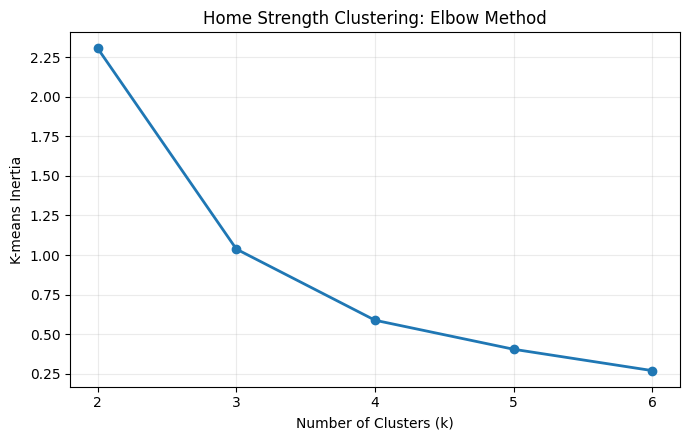

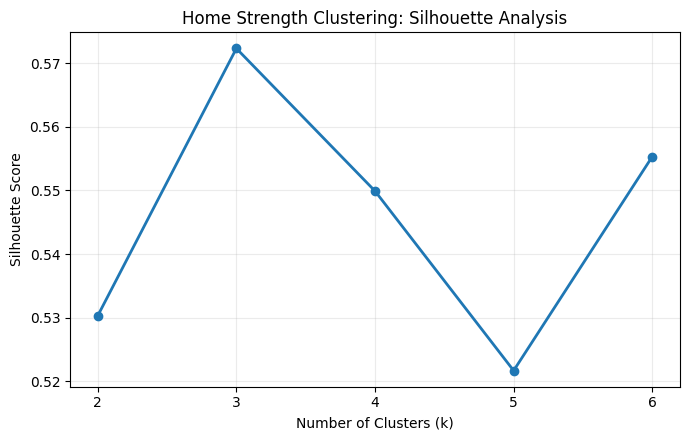

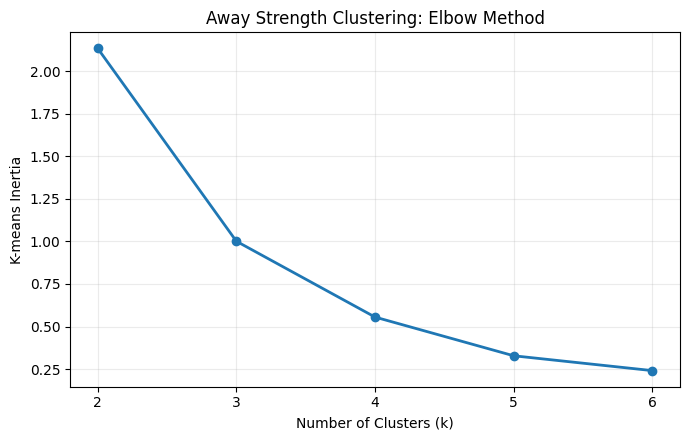

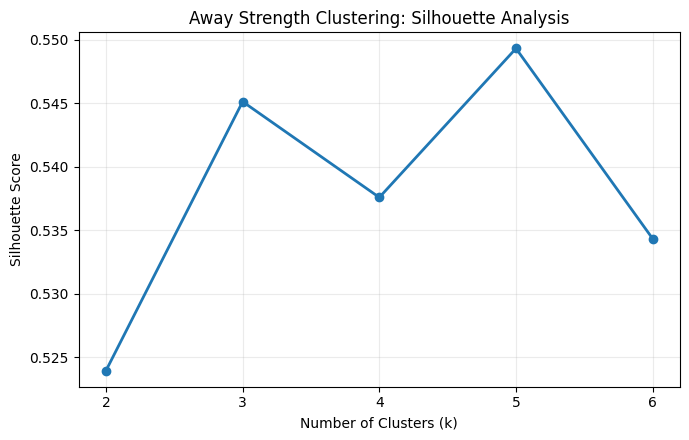

In [24]:
# --------------------------------------------------
# Elbow and Silhouette diagnostics
# --------------------------------------------------

for venue in ["Home", "Away"]:

    venue_diag = (
        cluster_diagnostics.loc[
            cluster_diagnostics["Venue"]
            == venue
        ]
        .sort_values("k")
    )

    # ------------------------------
    # Elbow plot
    # ------------------------------
    plt.figure(figsize=(7, 4.5))

    plt.plot(
        venue_diag["k"],
        venue_diag["Inertia"],
        marker="o",
        linewidth=2
    )

    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("K-means Inertia")

    plt.title(
        f"{venue} Strength Clustering: Elbow Method"
    )

    plt.xticks(
        venue_diag["k"]
    )

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()


    # ------------------------------
    # Silhouette plot
    # ------------------------------
    plt.figure(figsize=(7, 4.5))

    plt.plot(
        venue_diag["k"],
        venue_diag["Silhouette"],
        marker="o",
        linewidth=2
    )

    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Silhouette Score")

    plt.title(
        f"{venue} Strength Clustering: Silhouette Analysis"
    )

    plt.xticks(
        venue_diag["k"]
    )

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

### 4.1 Selection of the Number of Competitive Tiers

The clustering diagnostics suggest a relatively coarse tier structure.

For the home strength index, the Silhouette score reaches its maximum at
$k=3$, while the Elbow curve also shows that the largest reduction in
within-cluster dispersion occurs before the curve begins to flatten around
three clusters.

For the away strength index, the maximum Silhouette score occurs at $k=5$,
but the score at $k=3$ is nearly identical. Given the similar separation
quality, the clearer Elbow structure, and the preference for a parsimonious
and consistently interpretable representation across venues, three clusters
are retained for both home and away strength.

Thus,

$$
k_H=k_A=3.
$$

The resulting clusters are interpreted as broad competitive tiers rather
than strict discrete levels of football ability. Team strength remains a
continuous quantity; clustering is used only to summarize this continuous
axis into a small number of interpretable groups.

In [25]:
# --------------------------------------------------
# Final competitive-tier clustering
# --------------------------------------------------

K_FINAL = 3

TIER_NAMES = [
    "Lower",
    "Competitive",
    "Elite"
]

calibration_data["Tier"] = None

cluster_center_records = []


for venue in ["Home", "Away"]:

    mask = (
        calibration_data["Venue"]
        == venue
    )

    X = (
        calibration_data.loc[
            mask,
            ["Strength_Final"]
        ]
        .to_numpy()
    )

    model = KMeans(
        n_clusters=K_FINAL,
        random_state=42,
        n_init=50
    )

    raw_labels = model.fit_predict(X)

    centers = (
        model.cluster_centers_
        .flatten()
    )

    # KMeans labels (0,1,2) have no strength meaning.
    # Sort clusters from weakest to strongest.
    center_order = np.argsort(centers)

    label_mapping = {
        raw_label: TIER_NAMES[position]
        for position, raw_label
        in enumerate(center_order)
    }

    final_labels = [
        label_mapping[label]
        for label in raw_labels
    ]

    calibration_data.loc[
        mask,
        "Tier"
    ] = final_labels

    # Save ordered cluster centers
    for position, raw_label in enumerate(center_order):

        cluster_center_records.append({
            "Venue": venue,
            "Tier": TIER_NAMES[position],
            "Center": centers[raw_label]
        })


cluster_centers = pd.DataFrame(
    cluster_center_records
)

display(
    cluster_centers.round(4)
)

,Venue,Tier,Center
0,Home,Lower,-0.2913
1,Home,Competitive,0.0535
2,Home,Elite,0.3900
3,Away,Lower,-0.3357
4,Away,Competitive,-0.0519
5,Away,Elite,0.3230


In [26]:
latest_season = sorted(
    calibration_data["Season"].unique()
)[-1]


latest_tiers = (
    calibration_data.loc[
        calibration_data["Season"]
        == latest_season,
        [
            "Team",
            "Venue",
            "Strength_Final",
            "Tier",
            "Rank"
        ]
    ]
    .sort_values(
        [
            "Venue",
            "Strength_Final"
        ],
        ascending=[
            True,
            False
        ]
    )
)

display(
    latest_tiers
)

,Team,Venue,Strength_Final,Tier,Rank
160,Arsenal,Away,0.227943,Elite,1
184,Man City,Away,0.209236,Elite,2
172,Chelsea,Away,0.094554,Competitive,5
194,Tottenham,Away,0.074227,Competitive,6
182,Liverpool,Away,0.064876,Competitive,10
164,Bournemouth,Away,0.014820,Competitive,8
190,Nott'm Forest,Away,0.005746,Competitive,9
186,Man United,Away,-0.007558,Competitive,3
162,Aston Villa,Away,-0.098689,Competitive,4
176,Everton,Away,-0.105908,Competitive,7


In [27]:
# --------------------------------------------------
# Competitive-tier validation against league ranking
# --------------------------------------------------

tier_summary = (
    calibration_data
    .groupby(
        ["Venue", "Tier"],
        observed=True
    )
    .agg(
        Observations=(
            "Team",
            "size"
        ),

        Mean_Strength=(
            "Strength_Final",
            "mean"
        ),

        Mean_Rank=(
            "Rank",
            "mean"
        ),

        Median_Rank=(
            "Rank",
            "median"
        ),

        Best_Rank=(
            "Rank",
            "min"
        ),

        Worst_Rank=(
            "Rank",
            "max"
        )
    )
    .reset_index()
)


tier_order = {
    "Lower": 0,
    "Competitive": 1,
    "Elite": 2
}

tier_summary["Tier_Order"] = (
    tier_summary["Tier"]
    .map(tier_order)
)

tier_summary = (
    tier_summary
    .sort_values(
        ["Venue", "Tier_Order"]
    )
    .drop(
        columns="Tier_Order"
    )
)

display(
    tier_summary.round(3)
)

,Venue,Tier,Observations,Mean_Strength,Mean_Rank,Median_Rank,Best_Rank,Worst_Rank
2,Away,Lower,29,-0.336,16.793,18.0,12,20
0,Away,Competitive,58,-0.052,9.276,9.0,3,17
1,Away,Elite,13,0.323,1.923,2.0,1,4
5,Home,Lower,16,-0.291,18.375,19.0,14,20
3,Home,Competitive,59,0.054,11.322,11.0,4,19
4,Home,Elite,25,0.390,3.520,3.0,1,9


In [33]:
# --------------------------------------------------
# Five-season competitive-tier matrix
# --------------------------------------------------

TIER_TO_NUM = {
    "Lower": 0,
    "Competitive": 1,
    "Elite": 2
}

SEASONS = sorted(
    calibration_data["Season"].unique()
)


def build_tier_matrix(
    df,
    venue
):
    """
    Construct Team x Season matrices for:
    1. competitive tier
    2. scalar strength
    """

    venue_df = df.loc[
        df["Venue"] == venue
    ].copy()

    tier_matrix = (
        venue_df
        .pivot(
            index="Team",
            columns="Season",
            values="Tier"
        )
        .reindex(
            columns=SEASONS
        )
    )

    strength_matrix = (
        venue_df
        .pivot(
            index="Team",
            columns="Season",
            values="Strength_Final"
        )
        .reindex(
            columns=SEASONS
        )
    )

    # Convert tier names to numbers
    tier_numeric = tier_matrix.replace(
        TIER_TO_NUM
    ).astype(float)

    # Sort teams according to average strength
    mean_strength = (
        strength_matrix.mean(
            axis=1,
            skipna=True
        )
    )

    team_order = (
        mean_strength
        .sort_values(
            ascending=False
        )
        .index
    )

    tier_numeric = (
        tier_numeric
        .reindex(team_order)
    )

    strength_matrix = (
        strength_matrix
        .reindex(team_order)
    )

    return (
        tier_numeric,
        strength_matrix
    )


home_tier_matrix, home_strength_matrix = (
    build_tier_matrix(
        calibration_data,
        "Home"
    )
)

away_tier_matrix, away_strength_matrix = (
    build_tier_matrix(
        calibration_data,
        "Away"
    )
)

C:\Users\TK\AppData\Local\Temp\ipykernel_15872\2771826722.py:55: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tier_numeric = tier_matrix.replace(
C:\Users\TK\AppData\Local\Temp\ipykernel_15872\2771826722.py:55: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tier_numeric = tier_matrix.replace(


In [34]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


def plot_tier_heatmap(
    tier_matrix,
    strength_matrix,
    venue
):

    # Lower / Competitive / Elite
    cmap = ListedColormap([
        "#D9D9D9",
        "#8FBBD9",
        "#355C7D"
    ])

    cmap.set_bad(
        color="#F5F5F5"
    )

    fig, ax = plt.subplots(
        figsize=(
            10,
            max(
                7,
                len(tier_matrix) * 0.38
            )
        )
    )

    masked_data = np.ma.masked_invalid(
        tier_matrix.to_numpy(
            dtype=float
        )
    )

    ax.imshow(
        masked_data,
        cmap=cmap,
        vmin=0,
        vmax=2,
        aspect="auto"
    )

    # ------------------------------
    # Axis labels
    # ------------------------------
    ax.set_xticks(
        np.arange(
            len(tier_matrix.columns)
        )
    )

    ax.set_xticklabels(
        tier_matrix.columns
    )

    ax.set_yticks(
        np.arange(
            len(tier_matrix.index)
        )
    )

    ax.set_yticklabels(
        tier_matrix.index
    )

    ax.set_xlabel(
        "Season"
    )

    ax.set_ylabel(
        "Team"
    )

    ax.set_title(
        f"Five-Season {venue} Competitive-Tier Evolution"
    )

    # ------------------------------
    # Annotate scalar strength
    # ------------------------------
    for i, team in enumerate(
        tier_matrix.index
    ):

        for j, season in enumerate(
            tier_matrix.columns
        ):

            strength = (
                strength_matrix
                .loc[
                    team,
                    season
                ]
            )

            if pd.notna(strength):

                tier_value = (
                    tier_matrix
                    .loc[
                        team,
                        season
                    ]
                )

                # White text on Elite,
                # dark text otherwise
                text_color = (
                    "white"
                    if tier_value == 2
                    else "black"
                )

                ax.text(
                    j,
                    i,
                    f"{strength:.2f}",
                    ha="center",
                    va="center",
                    fontsize=7.5,
                    color=text_color
                )

    # ------------------------------
    # Grid between cells
    # ------------------------------
    ax.set_xticks(
        np.arange(
            -0.5,
            len(tier_matrix.columns),
            1
        ),
        minor=True
    )

    ax.set_yticks(
        np.arange(
            -0.5,
            len(tier_matrix.index),
            1
        ),
        minor=True
    )

    ax.grid(
        which="minor",
        linewidth=0.6,
        alpha=0.4
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    # ------------------------------
    # Legend
    # ------------------------------
    legend_elements = [
        Patch(
            facecolor="#D9D9D9",
            label="Lower"
        ),
        Patch(
            facecolor="#8FBBD9",
            label="Competitive"
        ),
        Patch(
            facecolor="#355C7D",
            label="Elite"
        ),
        Patch(
            facecolor="#F5F5F5",
            edgecolor="gray",
            label="Not in EPL"
        )
    ]

    ax.legend(
        handles=legend_elements,
        title="Competitive Tier",
        bbox_to_anchor=(
            1.02,
            1
        ),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

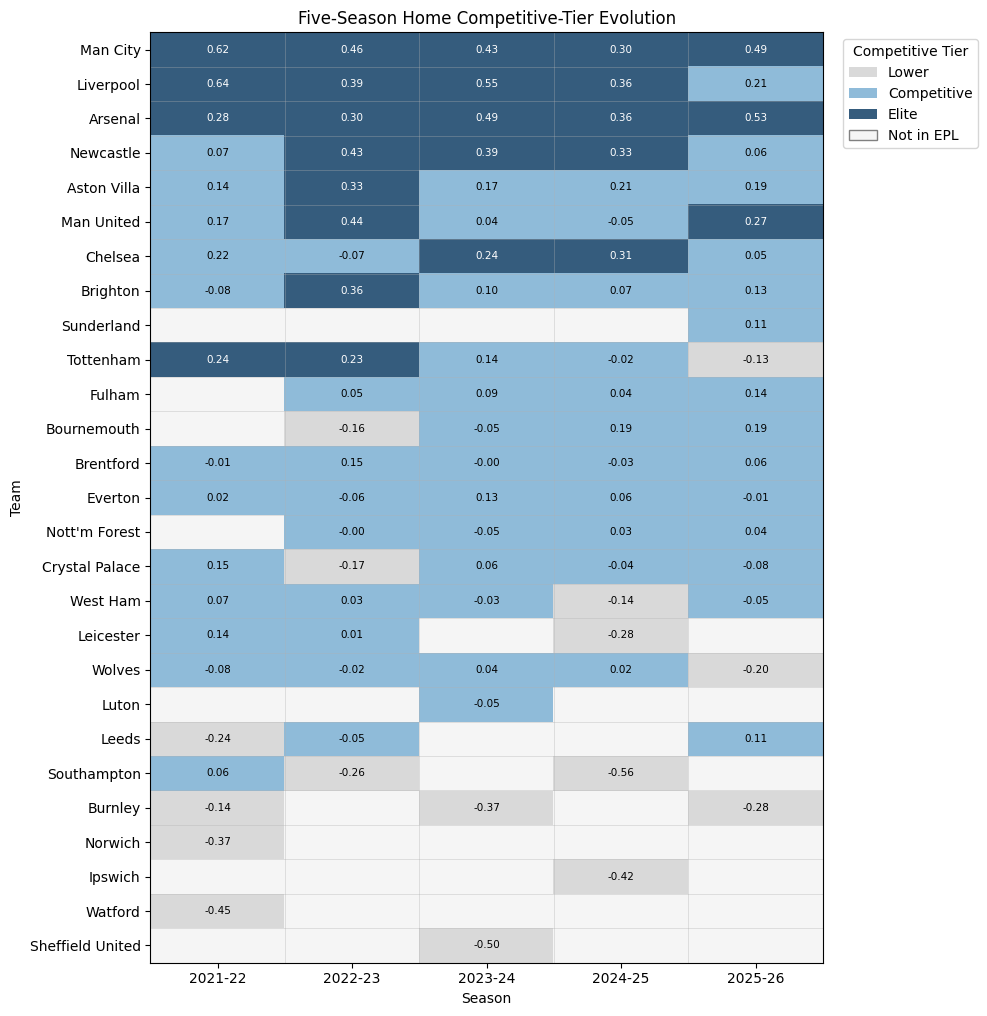

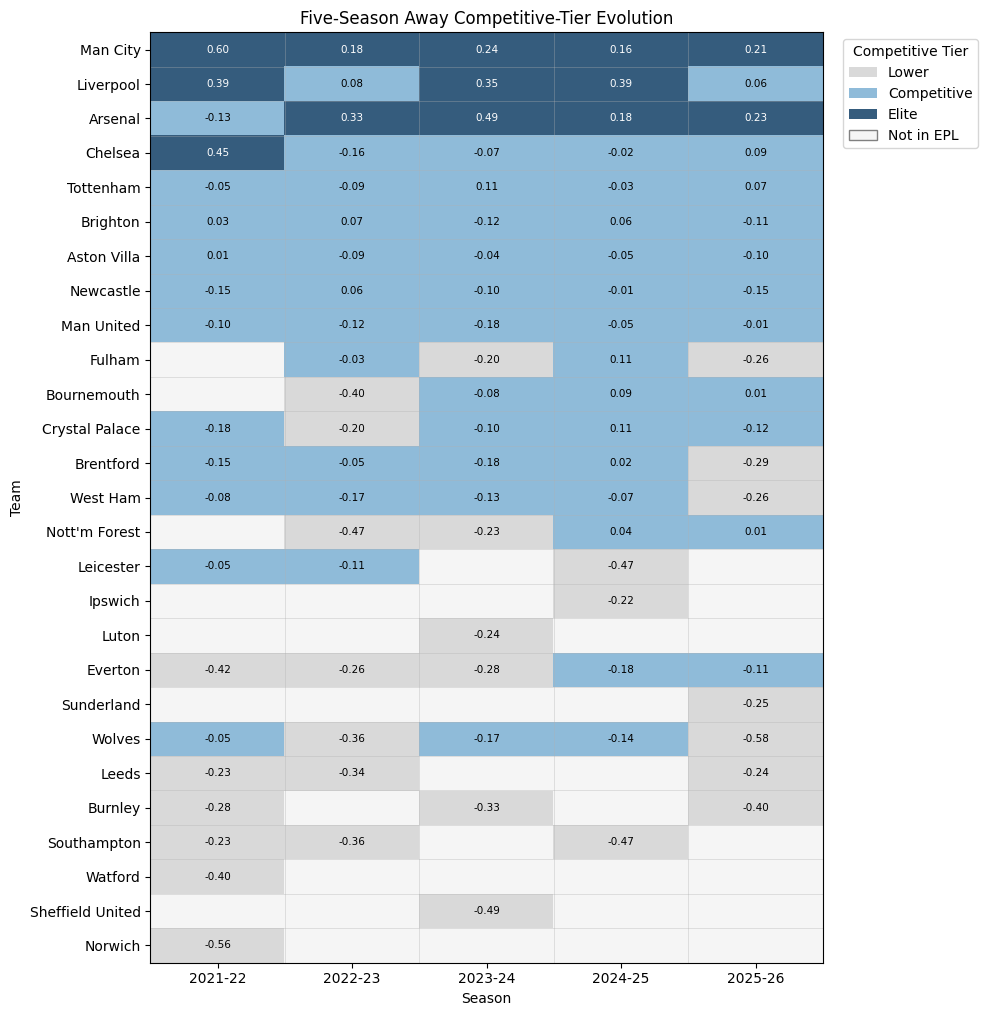

In [35]:
plot_tier_heatmap(
    home_tier_matrix,
    home_strength_matrix,
    "Home"
)

plot_tier_heatmap(
    away_tier_matrix,
    away_strength_matrix,
    "Away"
)

### 4.2 Competitive-Tier Structure Across Seasons

Using the fixed scalar strength indices, the pooled five-season clustering
produces three broad competitive tiers for both home and away performance:

$$
\mathrm{Lower}
<
\mathrm{Competitive}
<
\mathrm{Elite}.
$$

The heatmaps display the resulting tier assignments together with the
continuous scalar strength value for each team-season observation.

Because the clustering boundaries are estimated from all five seasons on a
common standardized strength scale, the tier labels are directly comparable
across seasons. A movement from one tier to another therefore represents a
change relative to a fixed multi-season strength structure rather than a
season-specific redefinition of competitive level.

The results show a clear long-run hierarchy among teams. Consistently strong
teams tend to remain in the Elite tier across multiple seasons, while weaker
or newly promoted teams are more frequently located in the Competitive or
Lower tiers. At the same time, several clubs move between tiers across
seasons, illustrating that the scalar index retains information about changes
in team strength rather than producing a fixed historical classification.

The home and away heatmaps also confirm that venue-specific strength should
remain separate. A team may occupy different competitive tiers in its home
and away states during the same season, reflecting differences in the
underlying venue-specific performance profiles.

Importantly, the three tiers should not be interpreted as discrete true
levels of football ability. The underlying strength variable remains
continuous:

$$
S_{i,v}^{(t)} \in \mathbb{R}.
$$

Clustering is used only as an interpretable summary of this continuous
strength axis. Subsequent dynamic modeling therefore uses the scalar
strength value itself rather than the categorical tier label.

In [36]:
# --------------------------------------------------
# Export final strength-index results
# --------------------------------------------------

strength_output = calibration_data[
    [
        "Season",
        "Team",
        "Venue",
        "Shot_Diff",
        "SOT_Rate_Diff",
        "Finishing_Diff",
        "Corners_Diff",
        "Strength_Final",
        "Tier",
        "Rank"
    ]
].copy()


final_weight_table = pd.DataFrame({
    "Feature": FEATURES,
    "Home_Weight": FINAL_WEIGHTS["Home"],
    "Away_Weight": FINAL_WEIGHTS["Away"]
})


OUTPUT_FILE = "strength_index_final_results.xlsx"

with pd.ExcelWriter(
    OUTPUT_FILE,
    engine="openpyxl"
) as writer:

    strength_output.to_excel(
        writer,
        sheet_name="Team_Strength_Index",
        index=False
    )

    final_weight_table.to_excel(
        writer,
        sheet_name="Final_Weights",
        index=False
    )

    cluster_centers.to_excel(
        writer,
        sheet_name="Cluster_Centers",
        index=False
    )

    tier_summary.to_excel(
        writer,
        sheet_name="Tier_Summary",
        index=False
    )

print(
    f"Saved final strength-index results to: {OUTPUT_FILE}"
)

Saved final strength-index results to: strength_index_final_results.xlsx


## 5. Summary

This analysis converts the four-dimensional opponent-adjusted seasonal state
vector into a fixed one-dimensional strength index.

An equal-weight projection first demonstrated that the underlying state
vectors already contain strong information about venue-specific league
performance. Random weight search with leave-one-season-out validation then
showed that non-equal feature weights provide a modest but consistent
out-of-sample improvement. Multi-seed analysis further showed that the broad
weighting structure is stable to the random-search initialization.

The resulting fixed home and away projections define continuous scalar team
strength measures that are subsequently summarized using three broad
competitive tiers.

The scalar strength index, rather than the cluster label, is retained as the
main quantitative representation for subsequent dynamic analysis.

The next stage evaluates Elo as an external time-varying benchmark before the
strength representation is extended to a sequential Bayesian state model.